In [1]:
"""
Repeated stratified CV stability check (10 x 5-fold = 50 folds) for the top
3 models + soft voting — reproduces report section 4.4 in full:
  Table 4-2  Summary results (mean +/- std, 50 folds)
  Table 4-3  Detailed numeric summary (mean, std, min, max, median)
  Figure 4-23  Boxplots across the 4 models
  Table 4-4  Subject-level predictions on the held-out test set
  Table 4-5  Per-subject summary of Soft Voting predictions
  Figure 4-24 / 4-25  Soft Voting classification report + confusion matrix
  Figure 4-26  Model agreement and P(PD) per subject

The single 11-subject test set used elsewhere is small enough that one
lucky/unlucky split can swing F1 by ~0.1 -- this notebook exists to get a
trustworthy mean +/- std instead of one number.

Loads best_of from the saved pickle (from 03_model_comparison.ipynb) rather
than depending on that notebook having run in the same session.
"""

import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import TwoSlopeNorm
import joblib

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    accuracy_score, confusion_matrix, classification_report,
)

sys.path.append("..")  # so config.py (in the repo root) is importable from notebooks/
from config import RANDOM_STATE, FEATURE_MATRIX_PATH, PARTICIPANTS_TSV, ALL_RESULTS_PKL, MODELS_DIR, FIGURES_DIR

os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

SOFT_VOTE_THRESHOLD = 0.35
TOP3_NAMES = ["SVM_Linear", "LogisticRegression", "RidgeClassifier"]
N_REPEATS = 10
N_SPLITS = 5


def load_data():
    feat_df = pd.read_csv(FEATURE_MATRIX_PATH)
    subject_list = feat_df["Subject"].tolist()
    X = feat_df.drop(columns=["Subject"]).values

    participants_df = pd.read_csv(PARTICIPANTS_TSV, sep="\t")
    label_map = {"Control": 0, "PD-NC": 1, "PD-MCI": 1}
    y = np.array([
        label_map[participants_df.loc[participants_df["participant_id"] == s, "group"].values[0]]
        for s in subject_list
    ])
    return X, y


# load already-fitted models from disk (no re-running the 10-model comparison)
results = joblib.load(ALL_RESULTS_PKL)
best_of = results["best_of"]
y_test = results["y_test"]

# reload X, y and recreate the exact same train/test split used to build best_of
X, y = load_data()
X_train, X_test, y_train, y_test_check = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
assert np.array_equal(y_test_check, y_test), "Split doesn't match best_of's y_test"

top3_models = {name: best_of[name]["_model"] for name in TOP3_NAMES}
top3_thresholds = {name: best_of[name]["threshold"] for name in TOP3_NAMES}

print(f"Loaded {len(best_of)} models from {ALL_RESULTS_PKL}")
print(f"Soft-voting threshold: {SOFT_VOTE_THRESHOLD} (fixed)")
print(f"Repeated CV: {N_REPEATS} repeats x {N_SPLITS} folds = {N_REPEATS * N_SPLITS} total folds")


Loaded 10 models from C:/Users/XPRISTO/Desktop/PD_PROJECT\models\all_results.pkl
Soft-voting threshold: 0.35 (fixed)
Repeated CV: 10 repeats x 5 folds = 50 total folds


In [2]:
def soft_vote_probs(models_dict, X_data):
    probs = [models_dict[name].predict_proba(X_data)[:, 1] for name in TOP3_NAMES]
    return np.mean(probs, axis=0)


# repeated stratified CV: 50 folds, refit each fold, evaluate top 3 + soft voting
rskf = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS, random_state=RANDOM_STATE)
all_names = TOP3_NAMES + ["SoftVoting"]
scores = {name: {"f1": [], "auc": [], "prec": [], "rec": [], "acc": [], "tn": []} for name in all_names}

total_folds = N_REPEATS * N_SPLITS
print(f"Running {total_folds} folds...")

for fold_idx, (train_idx, test_idx) in enumerate(rskf.split(X, y)):
    X_tr, X_te = X[train_idx], X[test_idx]
    y_tr, y_te = y[train_idx], y[test_idx]

    fold_probs = []
    for name in TOP3_NAMES:
        model = top3_models[name]
        model.fit(X_tr, y_tr)
        prob = model.predict_proba(X_te)[:, 1]
        fold_probs.append(prob)

        pred = (prob >= top3_thresholds[name]).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_te, pred, labels=[0, 1]).ravel()

        scores[name]["f1"].append(f1_score(y_te, pred, zero_division=0))
        scores[name]["auc"].append(roc_auc_score(y_te, prob))
        scores[name]["prec"].append(precision_score(y_te, pred, zero_division=0))
        scores[name]["rec"].append(recall_score(y_te, pred, zero_division=0))
        scores[name]["acc"].append(accuracy_score(y_te, pred))
        scores[name]["tn"].append(tn)

    avg_prob = np.mean(fold_probs, axis=0)
    sv_pred = (avg_prob >= SOFT_VOTE_THRESHOLD).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te, sv_pred, labels=[0, 1]).ravel()

    scores["SoftVoting"]["f1"].append(f1_score(y_te, sv_pred, zero_division=0))
    scores["SoftVoting"]["auc"].append(roc_auc_score(y_te, avg_prob))
    scores["SoftVoting"]["prec"].append(precision_score(y_te, sv_pred, zero_division=0))
    scores["SoftVoting"]["rec"].append(recall_score(y_te, sv_pred, zero_division=0))
    scores["SoftVoting"]["acc"].append(accuracy_score(y_te, sv_pred))
    scores["SoftVoting"]["tn"].append(tn)

    if (fold_idx + 1) % 10 == 0:
        print(f"  completed fold {fold_idx + 1}/{total_folds}")

print("Done.")


Running 50 folds...
  completed fold 10/50
  completed fold 20/50
  completed fold 30/50
  completed fold 40/50
  completed fold 50/50
Done.


In [3]:
"""
Table 4-2 -- Repeated CV results: mean +/- std over 50 folds
"""
metrics = ["f1", "auc", "prec", "rec", "acc", "tn"]
headers = ["F1", "AUC", "Precision", "Recall", "Accuracy", "TN (mean)"]

rows = []
for name in all_names:
    row = {"Model": name}
    for m, h in zip(metrics, headers):
        vals = scores[name][m]
        row[h] = f"{np.mean(vals):.3f} \u00b1 {np.std(vals):.3f}"
    rows.append(row)

table_4_2 = pd.DataFrame(rows).set_index("Model")
print(f"Table 4-2 \u2014 Repeated CV results, mean \u00b1 std over {N_REPEATS * N_SPLITS} folds "
      f"(SoftVoting threshold = {SOFT_VOTE_THRESHOLD})\n")
table_4_2


Table 4-2 — Repeated CV results, mean ± std over 50 folds (SoftVoting threshold = 0.35)



,F1,AUC,Precision,Recall,Accuracy,TN (mean)
Model,,,,,,
SVM_Linear,0.735 ± 0.125,0.716 ± 0.181,0.709 ± 0.117,0.780 ± 0.167,0.673 ± 0.138,2.240 ± 1.124
LogisticRegression,0.734 ± 0.124,0.736 ± 0.194,0.717 ± 0.125,0.769 ± 0.167,0.675 ± 0.139,2.340 ± 1.107
RidgeClassifier,0.727 ± 0.149,0.742 ± 0.183,0.729 ± 0.153,0.746 ± 0.189,0.676 ± 0.159,2.500 ± 1.204
SoftVoting,0.756 ± 0.122,0.733 ± 0.188,0.710 ± 0.121,0.825 ± 0.162,0.689 ± 0.136,2.120 ± 1.107


In [4]:
"""
Table 4-3 -- Detailed numeric summary over 50 folds (mean, std, min, max, median)
"""
detail_rows = []
for name in all_names:
    for m, h in zip(metrics, headers):
        vals = np.array(scores[name][m])
        detail_rows.append({
            "Model": name, "Metric": h,
            "Mean": round(vals.mean(), 3), "Std": round(vals.std(), 3),
            "Min": round(vals.min(), 3), "Max": round(vals.max(), 3),
            "Median": round(np.median(vals), 3),
        })

table_4_3 = pd.DataFrame(detail_rows)
print("Table 4-3 \u2014 Detailed numeric summary over 50 folds\n")
table_4_3


Table 4-3 — Detailed numeric summary over 50 folds



,Model,Metric,Mean,Std,Min,Max,Median
0,SVM_Linear,F1,0.735,0.125,0.400,1.000,0.739
1,SVM_Linear,AUC,0.716,0.181,0.214,1.000,0.714
2,SVM_Linear,Precision,0.709,0.117,0.500,1.000,0.714
3,SVM_Linear,Recall,0.780,0.167,0.333,1.000,0.833
4,SVM_Linear,Accuracy,0.673,0.138,0.364,1.000,0.636
5,SVM_Linear,TN (mean),2.240,1.124,0.000,4.000,2.000
6,LogisticRegression,F1,0.734,0.124,0.400,0.933,0.750
7,LogisticRegression,AUC,0.736,0.194,0.107,1.000,0.758
8,LogisticRegression,Precision,0.717,0.125,0.500,1.000,0.683
9,LogisticRegression,Recall,0.769,0.167,0.333,1.000,0.833


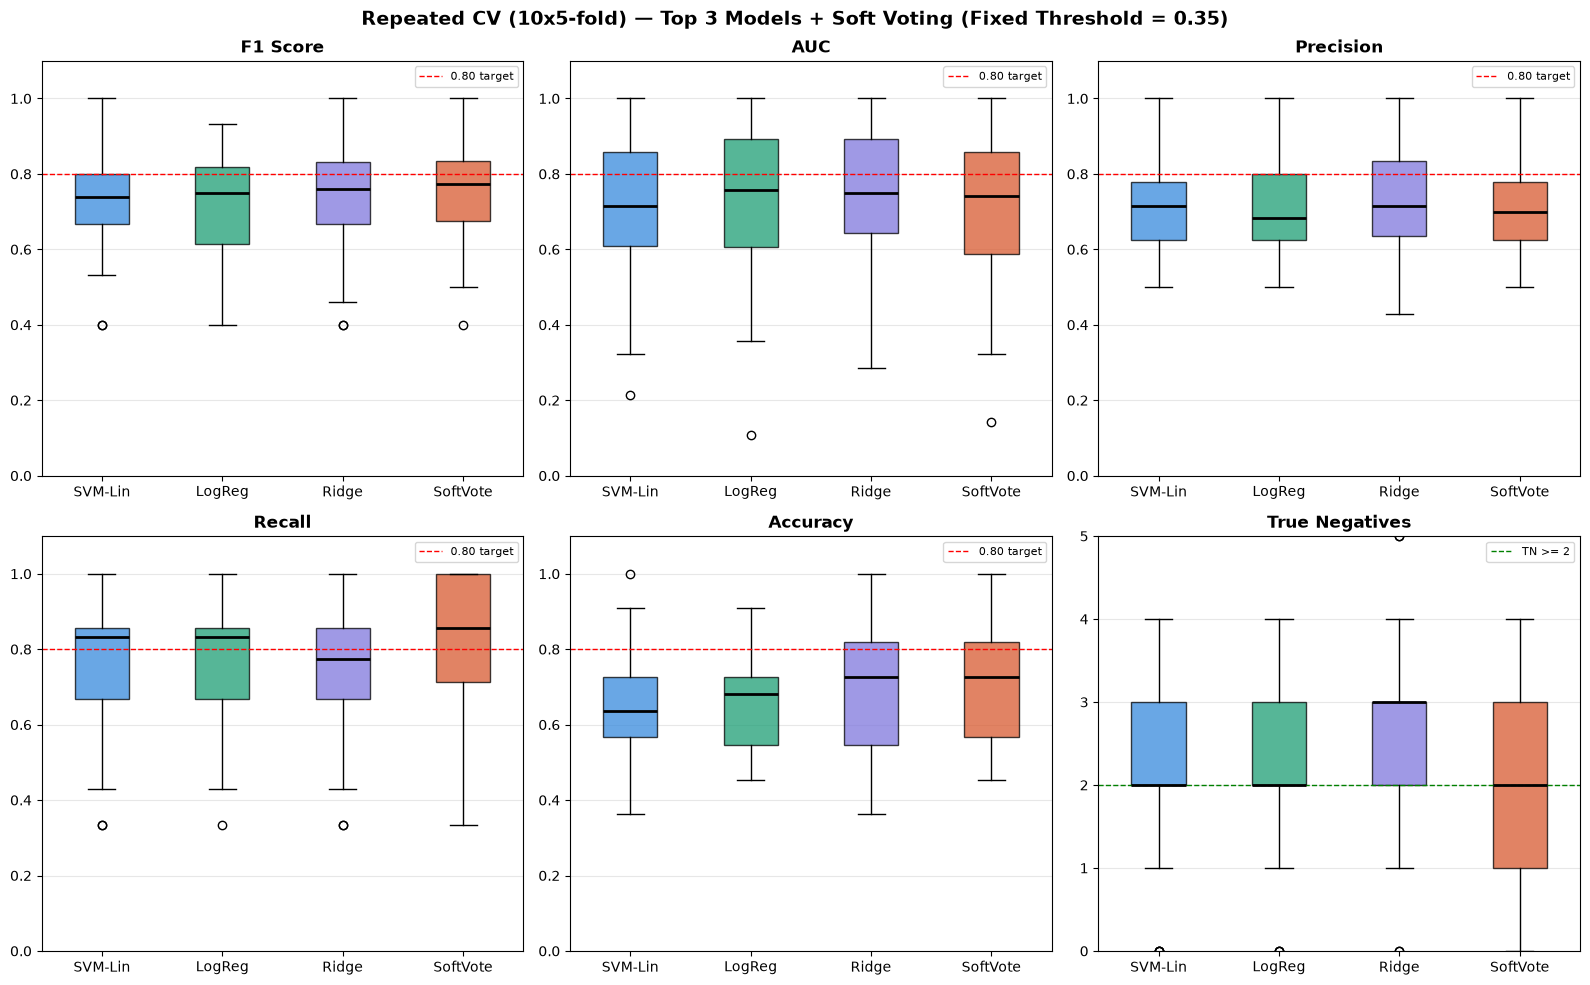

Saved: C:/Users/XPRISTO/Desktop/PD_PROJECT\figures\repeated_cv_boxplots.png


In [5]:
"""
Figure 4-23 -- Boxplots for F1, AUC, Precision, Recall, Accuracy, and TN
across the four evaluated models
"""
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(f"Repeated CV ({N_REPEATS}x{N_SPLITS}-fold) \u2014 Top 3 Models + Soft Voting "
             f"(Fixed Threshold = {SOFT_VOTE_THRESHOLD})", fontsize=14, fontweight="bold")

colors = ["#378ADD", "#1D9E75", "#7F77DD", "#D85A30"]
titles = ["F1 Score", "AUC", "Precision", "Recall", "Accuracy", "True Negatives"]

for ax, metric, title in zip(axes.flat, metrics, titles):
    data = [scores[name][metric] for name in all_names]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
    ax.set_title(title, fontweight="bold")
    ax.set_xticklabels(["SVM-Lin", "LogReg", "Ridge", "SoftVote"])
    ax.grid(axis="y", alpha=0.3)
    if metric != "tn":
        ax.axhline(0.80, color="red", linestyle="--", linewidth=1, label="0.80 target")
        ax.set_ylim(0, 1.1)
    else:
        ax.axhline(2, color="green", linestyle="--", linewidth=1, label="TN >= 2")
        ax.set_ylim(0, 5)
    ax.legend(fontsize=8)

plt.tight_layout()
fig_path = os.path.join(FIGURES_DIR, "repeated_cv_boxplots.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


In [6]:
"""
Subject-level analysis on the held-out test set: fit each of the 3 models
on the full training set, predict on the original 11 test subjects, and
build Table 4-4 (per-model grid) + Table 4-5 (Soft Voting summary).
"""
n_subjects = len(y_test)
subject_labels = [f"S{i+1:02d}" for i in range(n_subjects)]
label_map = {0: "HC", 1: "PD"}

preds = {}
probs = {}
for name in TOP3_NAMES:
    model = top3_models[name]
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    probs[name] = prob
    preds[name] = (prob >= top3_thresholds[name]).astype(int)

avg_prob = np.stack([probs[n] for n in TOP3_NAMES], axis=1).mean(axis=1)
preds["SoftVoting"] = (avg_prob >= SOFT_VOTE_THRESHOLD).astype(int)
probs["SoftVoting"] = avg_prob
all_model_names = TOP3_NAMES + ["SoftVoting"]

votes_pd = np.array([
    sum(preds[name][i] == 1 for name in TOP3_NAMES)
    for i in range(n_subjects)
])
agree_pct = (votes_pd / len(TOP3_NAMES) * 100).astype(int)

print("done")


done


In [7]:
"""
Table 4-4 -- Subject-level predictions for the top three individual models
and the Soft Voting ensemble
"""
table_4_4 = pd.DataFrame({
    "Subject": subject_labels,
    "True_Label": [label_map[y_test[i]] for i in range(n_subjects)],
    **{name: [f"{label_map[preds[name][i]]}{'\u2713' if preds[name][i]==y_test[i] else '\u2717'}"
              for i in range(n_subjects)] for name in all_model_names},
    "Votes_for_PD": votes_pd,
    "Agreement_%": agree_pct,
    "Avg_Prob_PD": np.round(avg_prob, 3),
})
table_4_4


,Subject,True_Label,SVM_Linear,LogisticRegression,RidgeClassifier,SoftVoting,Votes_for_PD,Agreement_%,Avg_Prob_PD
0,S01,HC,PD✗,HC✓,HC✓,PD✗,1,33,0.471
1,S02,HC,HC✓,HC✓,HC✓,HC✓,0,0,0.120
2,S03,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.833
3,S04,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.734
4,S05,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.589
5,S06,HC,HC✓,HC✓,HC✓,HC✓,0,0,0.331
6,S07,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.461
7,S08,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.904
8,S09,PD,PD✓,PD✓,PD✓,PD✓,3,100,0.954
9,S10,HC,PD✗,PD✗,PD✗,PD✗,3,100,0.518


In [8]:
"""
Table 4-5 -- Per-subject summary of Soft Voting ensemble predictions
"""
table_4_5 = pd.DataFrame({
    "Subject": subject_labels,
    "True_Label": [label_map[y_test[i]] for i in range(n_subjects)],
    "SoftVote": [f"{label_map[preds['SoftVoting'][i]]}{'\u2713' if preds['SoftVoting'][i]==y_test[i] else '\u2717'}"
                 for i in range(n_subjects)],
    "Avg_Prob": np.round(avg_prob, 3),
    "Votes_PD": votes_pd,
    "Agree_%": agree_pct,
    "Result": np.where(preds["SoftVoting"] == y_test, "Correct", "WRONG"),
})
n_correct = (table_4_5["Result"] == "Correct").sum()
print(f"Soft Voting correctly classified {n_correct}/{n_subjects} test subjects "
      f"({n_correct/n_subjects*100:.1f}%)\n")
table_4_5


Soft Voting correctly classified 9/11 test subjects (81.8%)



,Subject,True_Label,SoftVote,Avg_Prob,Votes_PD,Agree_%,Result
0,S01,HC,PD✗,0.471,1,33,WRONG
1,S02,HC,HC✓,0.120,0,0,Correct
2,S03,PD,PD✓,0.833,3,100,Correct
3,S04,PD,PD✓,0.734,3,100,Correct
4,S05,PD,PD✓,0.589,3,100,Correct
5,S06,HC,HC✓,0.331,0,0,Correct
6,S07,PD,PD✓,0.461,3,100,Correct
7,S08,PD,PD✓,0.904,3,100,Correct
8,S09,PD,PD✓,0.954,3,100,Correct
9,S10,HC,PD✗,0.518,3,100,WRONG


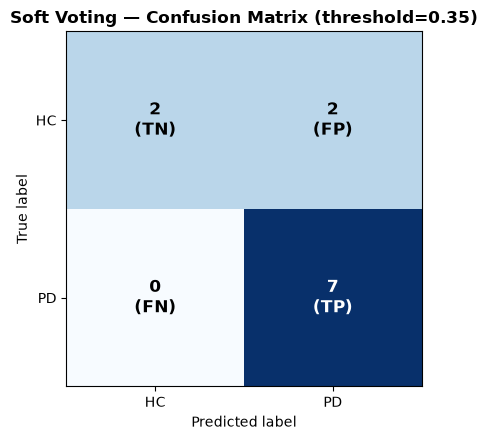

TN=2 FP=2 FN=0 TP=7

              precision    recall  f1-score   support

          HC       1.00      0.50      0.67         4
          PD       0.78      1.00      0.88         7

    accuracy                           0.82        11
   macro avg       0.89      0.75      0.77        11
weighted avg       0.86      0.82      0.80        11



In [9]:
"""
Figure 4-24 / 4-25 -- Soft Voting classification report + confusion matrix
"""
cm = confusion_matrix(y_test, preds["SoftVoting"], labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["HC", "PD"]); ax.set_yticklabels(["HC", "PD"])
ax.set_xlabel("Predicted label"); ax.set_ylabel("True label")
labels_grid = np.array([["TN", "FP"], ["FN", "TP"]])
thresh = cm.max() / 2
for row in range(2):
    for col in range(2):
        color = "white" if cm[row, col] > thresh else "black"
        ax.text(col, row, f"{cm[row, col]}\n({labels_grid[row, col]})",
                ha="center", va="center", fontsize=12, fontweight="bold", color=color)
ax.set_title(f"Soft Voting \u2014 Confusion Matrix (threshold={SOFT_VOTE_THRESHOLD})", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "soft_voting_confusion_matrix_cv.png"), dpi=150, bbox_inches="tight")
plt.show()

print(f"TN={tn} FP={fp} FN={fn} TP={tp}\n")
print(classification_report(y_test, preds["SoftVoting"], target_names=["HC", "PD"], zero_division=0))


C:\Users\XPRISTO\AppData\Local\Temp\ipykernel_33348\457236750.py:65: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.96])


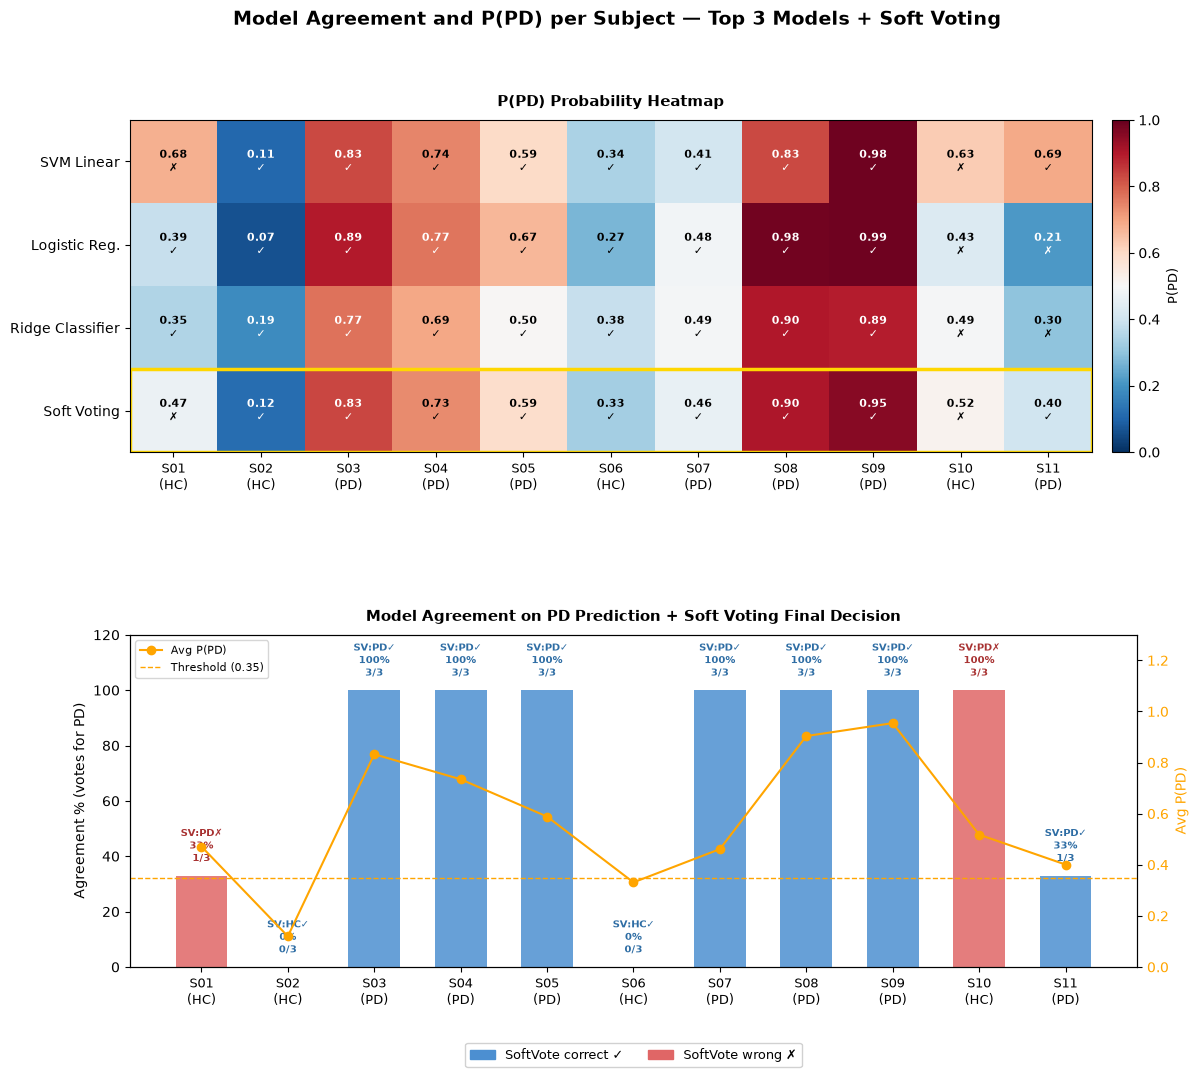

Saved: C:/Users/XPRISTO/Desktop/PD_PROJECT\figures\model_agreement_probability_cv.png


In [10]:
"""
Figure 4-26 -- Model Agreement and P(PD) per subject, for the Top 3 models
and the Soft Voting ensemble model
"""
heatmap_models = TOP3_NAMES + ["SoftVoting"]
heatmap_row_labels = ["SVM Linear", "Logistic Reg.", "Ridge Classifier", "Soft Voting"]
true_label_str = [label_map[y_test[i]] for i in range(n_subjects)]
col_headers = [f"{subject_labels[i]}\n({true_label_str[i]})" for i in range(n_subjects)]

fig = plt.figure(figsize=(13, 11))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.55)
fig.suptitle("Model Agreement and P(PD) per Subject \u2014 Top 3 Models + Soft Voting",
             fontsize=14, fontweight="bold", y=0.98)

ax0 = fig.add_subplot(gs[0])
heat_data = np.array([probs[name] for name in heatmap_models])
norm = TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
im = ax0.imshow(heat_data, cmap="RdBu_r", norm=norm, aspect="auto")
ax0.set_xticks(range(n_subjects)); ax0.set_xticklabels(col_headers, fontsize=9)
ax0.set_yticks(range(len(heatmap_models))); ax0.set_yticklabels(heatmap_row_labels, fontsize=10)
ax0.set_title("P(PD) Probability Heatmap", fontsize=11, fontweight="bold", pad=10)

for r, name in enumerate(heatmap_models):
    for c in range(n_subjects):
        p = heat_data[r, c]
        t = top3_thresholds[name] if name in top3_thresholds else SOFT_VOTE_THRESHOLD
        pred_label = "PD" if p >= t else "HC"
        mark = "\u2713" if pred_label == true_label_str[c] else "\u2717"
        text_color = "white" if (p > 0.75 or p < 0.25) else "black"
        ax0.text(c, r, f"{p:.2f}\n{mark}", ha="center", va="center",
                  fontsize=8, color=text_color, fontweight="bold")

n_rows = len(heatmap_models)
rect = plt.Rectangle((-0.5, n_rows - 1 - 0.5), n_subjects, 1, fill=False, edgecolor="gold", linewidth=2.5)
ax0.add_patch(rect)
cbar = fig.colorbar(im, ax=ax0, fraction=0.025, pad=0.02)
cbar.set_label("P(PD)", fontsize=9)

ax1 = fig.add_subplot(gs[1])
bar_colors = ["#4C8FD1" if preds["SoftVoting"][i] == y_test[i] else "#E06666" for i in range(n_subjects)]
bars = ax1.bar(range(n_subjects), agree_pct, color=bar_colors, alpha=0.85, width=0.6)
for i, bar in enumerate(bars):
    sv_pred = label_map[preds["SoftVoting"][i]]
    sv_mark = "\u2713" if preds["SoftVoting"][i] == y_test[i] else "\u2717"
    label = f"SV:{sv_pred}{sv_mark}\n{agree_pct[i]}%\n{votes_pd[i]}/3"
    color = "#2E6DA4" if sv_mark == "\u2713" else "#A83232"
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
              label, ha="center", va="bottom", fontsize=7.5, color=color, fontweight="bold")
ax1.set_ylim(0, 120)
ax1.set_ylabel("Agreement % (votes for PD)")
ax1.set_xticks(range(n_subjects)); ax1.set_xticklabels(col_headers, fontsize=9)
ax1.set_title("Model Agreement on PD Prediction + Soft Voting Final Decision", fontsize=11, fontweight="bold", pad=10)

ax2 = ax1.twinx()
ax2.plot(range(n_subjects), avg_prob, color="orange", marker="o", linewidth=1.5, label="Avg P(PD)")
ax2.axhline(SOFT_VOTE_THRESHOLD, color="orange", linestyle="--", linewidth=1, label=f"Threshold ({SOFT_VOTE_THRESHOLD})")
ax2.set_ylabel("Avg P(PD)", color="orange"); ax2.set_ylim(0, 1.3)
ax2.tick_params(axis="y", labelcolor="orange")
ax2.legend(loc="upper left", fontsize=8)

legend_handles = [mpatches.Patch(color="#4C8FD1", label="SoftVote correct \u2713"),
                   mpatches.Patch(color="#E06666", label="SoftVote wrong \u2717")]
ax1.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.32), ncol=2, fontsize=9, framealpha=0.9)

plt.tight_layout(rect=[0, 0.02, 1, 0.96])
fig_path = os.path.join(FIGURES_DIR, "model_agreement_probability_cv.png")
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {fig_path}")


In [11]:
"""
Save all repeated-CV results and tables for later use (e.g. writing up the report)
"""
cv_results = {
    "scores": scores,
    "table_4_2": table_4_2,
    "table_4_3": table_4_3,
    "table_4_4": table_4_4,
    "table_4_5": table_4_5,
    "soft_vote_threshold": SOFT_VOTE_THRESHOLD,
    "n_repeats": N_REPEATS,
    "n_splits": N_SPLITS,
}
cv_results_path = os.path.join(MODELS_DIR, "repeated_cv_results.pkl")
joblib.dump(cv_results, cv_results_path)
print(f"Saved: {cv_results_path}")


Saved: C:/Users/XPRISTO/Desktop/PD_PROJECT\models\repeated_cv_results.pkl
